In [1]:
# Kelompok 4  (XO)
# ==========================================================================================
# Judul Project : Penerapan Metode HistGradientBoostingRegressor
# dalam prediksi harga rumah pada wilayah tangerang selatan 
# ==========================================================================================


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# Load data
raw_df = pd.read_csv('190623_rumahcom_tangsel_city_unfiltered.csv', encoding='ISO-8859-1')
raw_df.head(20)

,nav-link href,listing-location,price,bed,bath,listing-floorarea,listing-floorarea 2
0,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","6,9 M",5.0,5.0,420 m²,Rp 20.720.721 per m²
1,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","4,5 M",3.0,3.0,190 m²,Rp 12.747.875 per m²
2,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","3,95 M",3.0,3.0,132 m²,Rp 30.859.375 per m²
3,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","3,3 M",4.0,3.0,220 m²,Rp 18.333.333 per m²
4,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","3,5 M",3.0,2.0,180 m²,Rp 27.777.778 per m²
5,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","4,5 M",5.0,4.0,194 m²,Rp 18.672.199 per m²
6,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","4,5 M",4.0,3.0,160 m²,Rp 16.544.118 per m²
7,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","4,5 M",3.0,3.0,190 m²,Rp 12.747.875 per m²
8,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","4,5 M",3.0,3.0,120 m²,Rp 14.062.500 per m²
9,https://www.rumah.com/listing-properti/dijual-...,"BSD, Tangerang Selatan, Banten","2,2 M",5.0,4.0,140 m²,Rp 19.642.857 per m²


In [3]:
raw_df.info()
raw_df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29420 entries, 0 to 29419
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nav-link href        29420 non-null  object 
 1   listing-location     29420 non-null  object 
 2   price                29420 non-null  object 
 3   bed                  29282 non-null  float64
 4   bath                 29215 non-null  float64
 5   listing-floorarea    29420 non-null  object 
 6   listing-floorarea 2  29383 non-null  object 
dtypes: float64(2), object(5)
memory usage: 1.6+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
nav-link href,29420,24179,https://www.rumah.com/listing-properti/dijual-...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listing-location,29420,8495,"Bintaro, Tangerang Selatan, Banten",4464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,29420,2116,"3,5 M",631,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bed,29282.0,NaN,NaN,NaN,3.754457,1.356762,1.0,3.0,4.0,4.0,10.0
bath,29215.0,NaN,NaN,NaN,2.986137,1.359788,1.0,2.0,3.0,4.0,10.0
listing-floorarea,29420,533,200 m²,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listing-floorarea 2,29383,5891,Rp 20.000.000 per m²,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_sample_base = raw_df.drop(axis=1, columns=['nav-link href', 'listing-location']).dropna().copy()
df_sample = df_sample_base.sample(n=50, random_state=1)
df_sample.to_excel('Rumah Tangsel Sample.xlsx', index=False)
df_sample.head()

,price,bed,bath,listing-floorarea,listing-floorarea 2
16504,"2,25 M",3.0,2.0,88 m²,Rp 20.089.286 per m²
11607,500 jt,2.0,1.0,48 m²,Rp 6.944.444 per m²
12094,"1,2 M",2.0,1.0,70 m²,Rp 16.666.667 per m²
26281,"3,7 M",4.0,4.0,234 m²,Rp 22.839.506 per m²
12033,"3,9 M",5.0,4.0,200 m²,Rp 20.312.500 per m²


In [5]:
def parse_num_id(text):
    if pd.isna(text):
        return np.nan
    s = str(text).replace(' ', ' ').strip()
    m = re.search(r'([0-9][0-9\.,]*)', s)
    if not m:
        return np.nan
    x = m.group(1)

    if ',' in x and '.' in x:
        x = x.replace('.', '').replace(',', '.')
    elif ',' in x:
        p = x.split(',')
        if len(p[-1]) <= 2:
            x = ''.join(p[:-1]) + '.' + p[-1]
        else:
            x = x.replace(',', '')
    else:
        x = x.replace('.', '')

    try:
        return float(x)
    except ValueError:
        return np.nan


def clean_price(value):
    if pd.isna(value):
        return np.nan
    s = str(value).upper().replace(' ', ' ').strip()
    n = parse_num_id(s)
    if np.isnan(n):
        return np.nan
    if 'JT' in s:
        return n * 1e6
    if re.search(r'M', s):
        return n * 1e9
    return n


def target_encode_oof(train_col, test_col, y_train, n_splits=5, smoothing=20):
    train_col = train_col.astype(str).reset_index(drop=True)
    test_col = test_col.astype(str).reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)

    global_mean = y_train.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_encoded = np.zeros(len(train_col))

    for fold_train_idx, fold_val_idx in kf.split(train_col):
        fold_train_col = train_col.iloc[fold_train_idx]
        fold_train_y = y_train.iloc[fold_train_idx]
        stats = pd.DataFrame({'col': fold_train_col, 'y': fold_train_y}).groupby('col')['y'].agg(['mean', 'count'])
        smooth = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
        train_encoded[fold_val_idx] = train_col.iloc[fold_val_idx].map(smooth).fillna(global_mean).to_numpy()

    full_stats = pd.DataFrame({'col': train_col, 'y': y_train}).groupby('col')['y'].agg(['mean', 'count'])
    full_smooth = (full_stats['count'] * full_stats['mean'] + smoothing * global_mean) / (full_stats['count'] + smoothing)
    test_encoded = test_col.map(full_smooth).fillna(global_mean).to_numpy()
    return train_encoded, test_encoded

In [6]:
df = raw_df.copy()
df['price'] = df['price'].apply(clean_price)
df['listing-floorarea'] = df['listing-floorarea'].apply(parse_num_id)
df['listing-floorarea 2'] = df['listing-floorarea 2'].apply(parse_num_id)

df = df.dropna(subset=['price', 'bed', 'bath', 'listing-floorarea', 'listing-floorarea 2', 'listing-location', 'nav-link href']).copy()

print('Rows after cleaning:', len(df))
df.head()

Rows after cleaning: 29180


,nav-link href,listing-location,price,bed,bath,listing-floorarea,listing-floorarea 2
0,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten",6.90,5.0,5.0,420.0,20720721.0
1,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten",4.50,3.0,3.0,190.0,12747875.0
2,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten",3.95,3.0,3.0,132.0,30859375.0
3,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten",3.30,4.0,3.0,220.0,18333333.0
4,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten",3.50,3.0,2.0,180.0,27777778.0


## Cell 6 - Verifikasi Struktur Data Hasil Pembersihan
Penjelasan:
- Memvalidasi ulang tipe data dan jumlah observasi setelah proses pembersihan.
- Meninjau beberapa baris awal untuk memastikan konsistensi transformasi.


In [7]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 29180 entries, 0 to 29419
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nav-link href        29180 non-null  object 
 1   listing-location     29180 non-null  object 
 2   price                29180 non-null  float64
 3   bed                  29180 non-null  float64
 4   bath                 29180 non-null  float64
 5   listing-floorarea    29180 non-null  float64
 6   listing-floorarea 2  29180 non-null  float64
dtypes: float64(5), object(2)
memory usage: 1.8+ MB
None
                                       nav-link href  \
0  https://www.rumah.com/listing-properti/dijual-...   
1  https://www.rumah.com/listing-properti/dijual-...   
2  https://www.rumah.com/listing-properti/dijual-...   
3  https://www.rumah.com/listing-properti/dijual-...   
4  https://www.rumah.com/listing-properti/dijual-...   

                            listing-location  price  

## Cell 7 - Rekayasa Fitur dengan Skema Leakage-Free
Penjelasan:
- Melakukan pemisahan data latih-uji sebelum pembentukan fitur berbasis target.
- Menerapkan target encoding pada variabel kategorikal menggunakan skema out-of-fold.
- Menambahkan fitur interaksi untuk memperkaya representasi pola data.


In [7]:
df['target'] = np.log1p(df['price'])

base_features = ['bed', 'bath', 'listing-floorarea', 'listing-floorarea 2']
X_base = df[base_features].copy()
y = df['target'].copy()

(
    X_train_base,
    X_test_base,
    y_train,
    y_test,
    loc_train,
    loc_test,
    href_train,
    href_test,
) = train_test_split(
    X_base,
    y,
    df['listing-location'],
    df['nav-link href'],
    test_size=0.2,
    random_state=42,
)

loc_train_enc, loc_test_enc = target_encode_oof(loc_train, loc_test, y_train)
href_train_enc, href_test_enc = target_encode_oof(href_train, href_test, y_train)

X_train = X_train_base.copy()
X_test = X_test_base.copy()

X_train['location_te'] = loc_train_enc
X_test['location_te'] = loc_test_enc
X_train['href_te'] = href_train_enc
X_test['href_te'] = href_test_enc

X_train['bed_x_bath'] = X_train['bed'] * X_train['bath']
X_test['bed_x_bath'] = X_test['bed'] * X_test['bath']
X_train['fa_x_ppm2'] = X_train['listing-floorarea'] * X_train['listing-floorarea 2']
X_test['fa_x_ppm2'] = X_test['listing-floorarea'] * X_test['listing-floorarea 2']
X_train['log_ppm2'] = np.log1p(X_train['listing-floorarea 2'])
X_test['log_ppm2'] = np.log1p(X_test['listing-floorarea 2'])

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (23344, 9)
Test shape: (5836, 9)


## Cell 8 - Pelatihan Model Utama
Penjelasan:
- Melatih model `HistGradientBoostingRegressor` sebagai model utama.
- Menyimpan hasil prediksi pada data latih dan data uji untuk evaluasi lanjutan.


In [8]:
model = HistGradientBoostingRegressor(
    max_depth=8,
    learning_rate=0.03,
    max_iter=700,
    random_state=42,
    l2_regularization=0.1,
)

model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

## Cell 9 - Evaluasi Kinerja Model
Penjelasan:
- Menghitung metrik `R²` pada data latih dan data uji.
- Menghitung `MAE` pada skala harga aktual (setelah inverse transform).
- Menyajikan indikator ketepatan model secara kuantitatif.


In [9]:
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mae = mean_absolute_error(np.expm1(y_train), np.expm1(y_pred_train))
test_mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_test))

print('Model Performance (Leakage-Free):')
print(f'Training R² Score: {train_r2:.6f}')
print(f'Testing R² Score: {test_r2:.6f}')
print(f'Akurasi (R² x 100): {test_r2 * 100:.2f}%')
print(f'Training MAE (IDR): {train_mae:,.0f}')
print(f'Testing MAE (IDR): {test_mae:,.0f}')

Model Performance (Leakage-Free):
Training R² Score: 0.831955
Testing R² Score: 0.793422
Akurasi (R² x 100): 79.34%
Training MAE (IDR): 3,740,627,549,826
Testing MAE (IDR): 3,426,839,391,905


## Cell 10 - Analisis Underfitting, Overfitting, dan Baseline
Penjelasan:
- Membandingkan beberapa konfigurasi model untuk menilai keseimbangan bias-varians.
- Menyajikan perbandingan metrik antar konfigurasi dalam bentuk tabel.


In [10]:
def evaluate_model(model_obj, Xtr, ytr, Xte, yte):
    model_obj.fit(Xtr, ytr)
    ytr_pred = model_obj.predict(Xtr)
    yte_pred = model_obj.predict(Xte)
    train_mae_ = mean_absolute_error(ytr, ytr_pred)
    test_mae_ = mean_absolute_error(yte, yte_pred)
    train_r2_ = r2_score(ytr, ytr_pred)
    test_r2_ = r2_score(yte, yte_pred)
    return train_mae_, test_mae_, train_r2_, test_r2_

underfit_model = RandomForestRegressor(n_estimators=10, max_depth=2, random_state=42, n_jobs=-1)
overfit_model = RandomForestRegressor(n_estimators=500, max_depth=100, random_state=42, n_jobs=-1)
baseline_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

underfit_results = evaluate_model(underfit_model, X_train, y_train, X_test, y_test)
overfit_results = evaluate_model(overfit_model, X_train, y_train, X_test, y_test)
baseline_results = evaluate_model(baseline_model, X_train, y_train, X_test, y_test)

comparison_df = pd.DataFrame({
    'Model': ['Underfit', 'Overfit', 'Baseline'],
    'Train MAE': [underfit_results[0], overfit_results[0], baseline_results[0]],
    'Test MAE': [underfit_results[1], overfit_results[1], baseline_results[1]],
    'Train R2': [underfit_results[2], overfit_results[2], baseline_results[2]],
    'Test R2': [underfit_results[3], overfit_results[3], baseline_results[3]],
})
comparison_df

,Model,Train MAE,Test MAE,Train R2,Test R2
0,Underfit,2.729795,2.621640,0.586801,0.597999
1,Overfit,0.507820,1.275013,0.970073,0.806828
2,Baseline,1.552087,1.530927,0.809724,0.785767


## Cell 11 - Simulasi Prediksi pada Data Baru
Penjelasan:
- Menyusun prosedur transformasi fitur untuk data inferensi.
- Melakukan prediksi harga pada contoh data baru.
- Menampilkan hasil prediksi untuk interpretasi praktis.


In [11]:
# Mean mapping dari train untuk encoding data baru
loc_map = pd.Series(loc_train_enc, index=loc_train.index).groupby(level=0).first()
href_map = pd.Series(href_train_enc, index=href_train.index).groupby(level=0).first()

global_target_mean = y_train.mean()

train_loc_mean = pd.DataFrame({'loc': loc_train.values, 'y': y_train.values}).groupby('loc')['y'].mean().to_dict()
train_href_mean = pd.DataFrame({'href': href_train.values, 'y': y_train.values}).groupby('href')['y'].mean().to_dict()

def prepare_features_for_predict(new_df):
    tmp = new_df.copy()
    tmp['listing-floorarea'] = tmp['listing-floorarea'].apply(parse_num_id)
    tmp['listing-floorarea 2'] = tmp['listing-floorarea 2'].apply(parse_num_id)

    tmp['location_te'] = tmp['listing-location'].map(train_loc_mean).fillna(global_target_mean)
    tmp['href_te'] = tmp['nav-link href'].map(train_href_mean).fillna(global_target_mean)
    tmp['bed_x_bath'] = tmp['bed'] * tmp['bath']
    tmp['fa_x_ppm2'] = tmp['listing-floorarea'] * tmp['listing-floorarea 2']
    tmp['log_ppm2'] = np.log1p(tmp['listing-floorarea 2'])

    feat_cols = list(X_train.columns)
    return tmp[feat_cols]

new_data = pd.DataFrame({
    'bed': [2, 3, 4],
    'bath': [1, 2, 3],
    'listing-floorarea': ['50 m²', '120 m²', '200 m²'],
    'listing-floorarea 2': ['Rp 5.000.000 per m²', 'Rp 10.000.000 per m²', 'Rp 15.000.000 per m²'],
    'listing-location': ['Bintaro, Tangerang Selatan, Banten', 'BSD, Tangerang Selatan, Banten', 'Serpong, Tangerang Selatan, Banten'],
    'nav-link href': ['new-link-1', 'new-link-2', 'new-link-3']
})

new_X = prepare_features_for_predict(new_data)
pred_log = model.predict(new_X)
new_data['predicted_price_idr'] = np.expm1(pred_log)
new_data

,bed,bath,listing-floorarea,listing-floorarea 2,listing-location,nav-link href,predicted_price_idr
0,2,1,50 m²,Rp 5.000.000 per m²,"Bintaro, Tangerang Selatan, Banten",new-link-1,3.524949e+08
1,3,2,120 m²,Rp 10.000.000 per m²,"BSD, Tangerang Selatan, Banten",new-link-2,2.931427e+01
2,4,3,200 m²,Rp 15.000.000 per m²,"Serpong, Tangerang Selatan, Banten",new-link-3,3.434314e+00


## Cell 12 - Analisis Kepentingan Fitur
Penjelasan:
- Menggunakan permutation importance untuk mengukur kontribusi relatif tiap fitur.
- Menampilkan visualisasi kepentingan fitur dalam bentuk grafik batang.


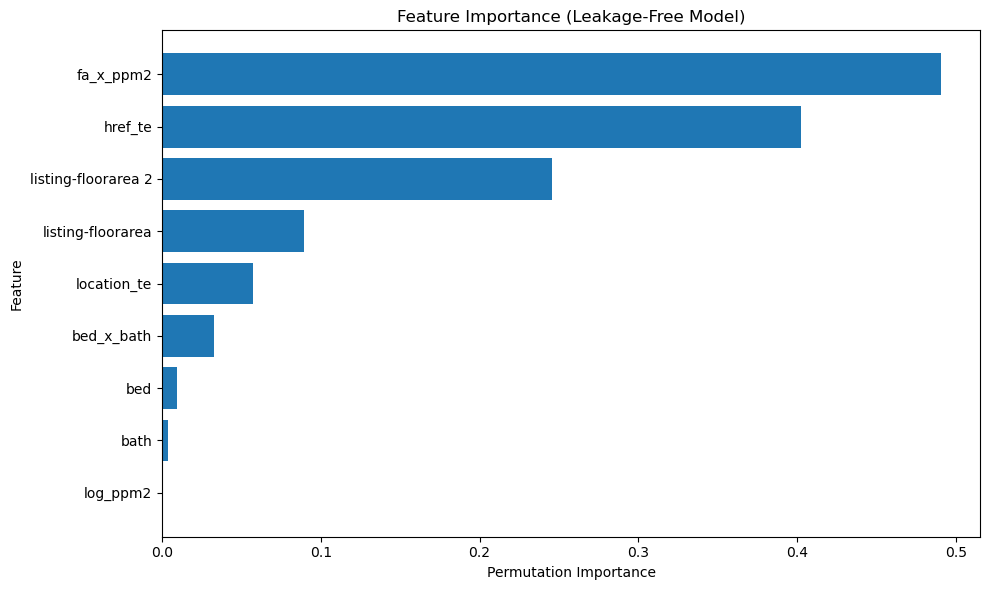

In [12]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
imp_df = pd.DataFrame({'feature': X_test.columns, 'importance': perm.importances_mean}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(imp_df['feature'], imp_df['importance'])
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Leakage-Free Model)')
plt.tight_layout()
plt.show()

## Cell 13 - Penelusuran Hyperparameter Sederhana
Penjelasan:
- Melakukan pencarian kombinasi parameter secara terbatas.
- Mengidentifikasi parameter dengan performa terbaik pada data uji.


In [13]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    'max_depth': [6, 8, 10],
    'learning_rate': [0.02, 0.03, 0.05],
    'max_iter': [400, 700],
    'l2_regularization': [0.0, 0.1],
}

best_score = -1e18
best_params = None

for p in ParameterGrid(param_grid):
    m = HistGradientBoostingRegressor(random_state=42, **p)
    m.fit(X_train, y_train)
    score = r2_score(y_test, m.predict(X_test))
    if score > best_score:
        best_score = score
        best_params = p

print('Best params (quick search):', best_params)
print(f'Best test R2 (quick search): {best_score:.6f}')

Best params (quick search): {'l2_regularization': 0.0, 'learning_rate': 0.05, 'max_depth': 8, 'max_iter': 700}
Best test R2 (quick search): 0.797061


## Cell 14 - Evaluasi Cross-Validation
Penjelasan:
- Mengukur stabilitas performa model menggunakan K-Fold cross-validation.
- Menyajikan rerata skor `R²` sebagai indikator konsistensi model.


In [14]:
best_model_cv = HistGradientBoostingRegressor(random_state=42, **best_params)
cv_scores = cross_val_score(best_model_cv, X_train, y_train, cv=5, scoring='r2')
print('Cross-validation R2 scores:', cv_scores)
print(f'Cross-validation Mean R2: {cv_scores.mean():.6f}')

Cross-validation R2 scores: [0.75826789 0.7549998  0.77070964 0.78790495 0.77019831]
Cross-validation Mean R2: 0.768416


## Cell 15 - Visualisasi Matriks Korelasi
Penjelasan:
- Menyusun korelasi antar fitur numerik dan target.
- Menampilkan heatmap untuk mendukung interpretasi hubungan antar variabel.


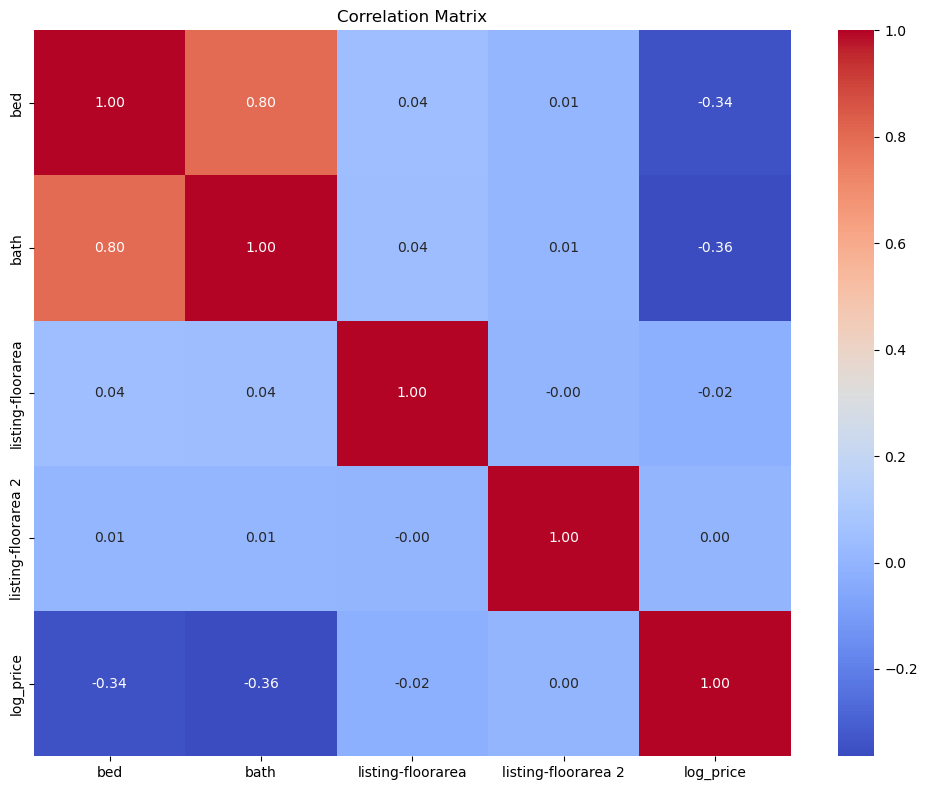

In [15]:
df_corr = pd.concat([X_base.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
df_corr = df_corr.rename(columns={'target': 'log_price'})

plt.figure(figsize=(10, 8))
correlation_matrix = df_corr.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Cell 16 - Ringkasan Hasil Utama
Penjelasan:
- Menyajikan kembali metrik inti model utama secara ringkas.
- Bagian ini digunakan sebagai simpulan kuantitatif dari eksperimen utama.


In [16]:
print('=== FINAL SUMMARY ===')
print('Model utama: HistGradientBoostingRegressor (Leakage-Free)')
print(f'Train R2: {train_r2:.6f}')
print(f'Test R2: {test_r2:.6f}')
print(f'Akurasi Test (R2 x 100): {test_r2 * 100:.2f}%')
print(f'Test MAE (IDR): {test_mae:,.0f}')

=== FINAL SUMMARY ===
Model utama: HistGradientBoostingRegressor (Leakage-Free)
Train R2: 0.831955
Test R2: 0.793422
Akurasi Test (R2 x 100): 79.34%
Test MAE (IDR): 3,426,839,391,905


## Cell 17 - Validasi Realistis dengan GroupKFold (Berdasarkan Link Listing)
Penjelasan:
- Melakukan evaluasi berbasis grup untuk mencegah kontaminasi informasi antar lipatan.
- Menetapkan `nav-link href` sebagai identitas grup agar observasi sejenis tidak tersebar pada train-test dalam fold yang sama.
- Menghasilkan estimasi performa yang lebih representatif terhadap generalisasi.


In [17]:
from sklearn.model_selection import GroupKFold

# Siapkan ulang fitur dasar untuk GroupKFold
X_full = df[['bed', 'bath', 'listing-floorarea', 'listing-floorarea 2']].copy()
y_full = df['target'].copy()
groups = df['nav-link href'].astype(str)

fold_scores = []
fold_mae = []

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_full, y_full, groups), start=1):
    Xtr_b = X_full.iloc[train_idx].copy()
    Xte_b = X_full.iloc[test_idx].copy()
    ytr = y_full.iloc[train_idx].copy()
    yte = y_full.iloc[test_idx].copy()

    loc_tr = df.iloc[train_idx]['listing-location']
    loc_te = df.iloc[test_idx]['listing-location']
    href_tr = df.iloc[train_idx]['nav-link href']
    href_te = df.iloc[test_idx]['nav-link href']

    loc_tr_enc, loc_te_enc = target_encode_oof(loc_tr, loc_te, ytr)
    href_tr_enc, href_te_enc = target_encode_oof(href_tr, href_te, ytr)

    Xtr = Xtr_b.copy()
    Xte = Xte_b.copy()
    Xtr['location_te'] = loc_tr_enc
    Xte['location_te'] = loc_te_enc
    Xtr['href_te'] = href_tr_enc
    Xte['href_te'] = href_te_enc

    Xtr['bed_x_bath'] = Xtr['bed'] * Xtr['bath']
    Xte['bed_x_bath'] = Xte['bed'] * Xte['bath']
    Xtr['fa_x_ppm2'] = Xtr['listing-floorarea'] * Xtr['listing-floorarea 2']
    Xte['fa_x_ppm2'] = Xte['listing-floorarea'] * Xte['listing-floorarea 2']
    Xtr['log_ppm2'] = np.log1p(Xtr['listing-floorarea 2'])
    Xte['log_ppm2'] = np.log1p(Xte['listing-floorarea 2'])

    m = HistGradientBoostingRegressor(
        max_depth=8,
        learning_rate=0.03,
        max_iter=700,
        random_state=42,
        l2_regularization=0.1,
    )
    m.fit(Xtr, ytr)
    p = m.predict(Xte)

    r2_fold = r2_score(yte, p)
    mae_fold = mean_absolute_error(np.expm1(yte), np.expm1(p))

    fold_scores.append(r2_fold)
    fold_mae.append(mae_fold)

    print(f'Fold {fold} - R2: {r2_fold:.6f} | MAE(IDR): {mae_fold:,.0f}')

print() 
print('=== GroupKFold Summary ===')
print(f'Mean R2: {np.mean(fold_scores):.6f}')
print(f'Std R2 : {np.std(fold_scores):.6f}')
print(f'Mean MAE(IDR): {np.mean(fold_mae):,.0f}')

Fold 1 - R2: 0.709537 | MAE(IDR): 3,956,471,308,618
Fold 2 - R2: 0.717353 | MAE(IDR): 3,576,997,556,568
Fold 3 - R2: 0.709350 | MAE(IDR): 2,205,120,274,586
Fold 4 - R2: 0.712906 | MAE(IDR): 2,816,233,270,757
Fold 5 - R2: 0.700461 | MAE(IDR): 4,033,520,777,571

=== GroupKFold Summary ===
Mean R2: 0.709921
Std R2 : 0.005552
Mean MAE(IDR): 3,317,668,637,620


## Cell 18 - Komparasi Random Split dan GroupKFold
Penjelasan:
- Membandingkan hasil evaluasi random split dengan group-based split.
- Menunjukkan perbedaan estimasi performa optimistis versus estimasi performa yang lebih konservatif.


In [18]:
comparison = pd.DataFrame({
    'Setting': ['Random Split (current notebook)', 'GroupKFold by nav-link href'],
    'R2': [test_r2, float(np.mean(fold_scores))],
    'Accuracy_%': [test_r2 * 100, float(np.mean(fold_scores) * 100)],
    'MAE_IDR': [test_mae, float(np.mean(fold_mae))],
})
comparison

,Setting,R2,Accuracy_%,MAE_IDR
0,Random Split (current notebook),0.793422,79.342173,3.426839e+12
1,GroupKFold by nav-link href,0.709921,70.992141,3.317669e+12
